In [51]:
# Cell 1: Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import random

In [52]:
# Cell 2: Base Setup (same as Part 1)

# Actions
actions = ["show_offer", "show_video", "send_notification"]

# User types
user_types = ["deal_hunter", "content_consumer", "casual"]

# Ground truth response probabilities (this is the "real world")
response_probs = {
    "deal_hunter": {
        "show_offer": 0.7,
        "show_video": 0.2,
        "send_notification": 0.4
    },
    "content_consumer": {
        "show_offer": 0.2,
        "show_video": 0.7,
        "send_notification": 0.3
    },
    "casual": {
        "show_offer": 0.3,
        "show_video": 0.3,
        "send_notification": 0.2
    }
}

# Function to simulate user response
def get_response(user_type, action, day):

    # Early phase
    if day < 5:
        probs = response_probs[user_type]

    # Later phase (preferences shift)
    else:
        probs = {
            "deal_hunter": {
                "show_offer": 0.4,
                "show_video": 0.5,
                "send_notification": 0.3
            },
            "content_consumer": {
                "show_offer": 0.5,
                "show_video": 0.4,
                "send_notification": 0.3
            },
            "casual": response_probs["casual"]
        }

    return int(np.random.rand() < probs[user_type][action])

In [53]:
def get_response(user_type, action, day):

    # Early phase
    if day < 5:
        probs = response_probs

    # Later phase (preferences shift)
    else:
        probs = {
            "deal_hunter": {
                "show_offer": 0.4,
                "show_video": 0.5,
                "send_notification": 0.3
            },
            "content_consumer": {
                "show_offer": 0.5,
                "show_video": 0.4,
                "send_notification": 0.3
            },
            "casual": {
                "show_offer": 0.3,
                "show_video": 0.3,
                "send_notification": 0.2
            }
        }

    return int(np.random.rand() < probs[user_type][action])

In [54]:
# Cell 4: Optimized score_action (fast + no warnings)

def score_action_fast(user_type, prev_action, prev_response, action):

    # Create empty feature dict with all columns
    row = {col: 0 for col in df_columns}

    # Set one-hot features
    if f"user_type_{user_type}" in row:
        row[f"user_type_{user_type}"] = 1

    if f"action_{action}" in row:
        row[f"action_{action}"] = 1

    if f"prev_action_{prev_action}" in row:
        row[f"prev_action_{prev_action}"] = 1

    # Set numeric feature
    row["prev_response"] = prev_response

    # Convert to DataFrame (keeps feature names → avoids warning)
    row_df = pd.DataFrame([row])

    # Predict probability
    prob = model.predict_proba(row_df)[0][1]

    return prob

In [55]:
class EpsilonGreedyAgent:

    def __init__(self, model, df_columns, actions,
                 epsilon_start=0.5,
                 epsilon_decay=0.95,
                 epsilon_min=0.05):

        self.model = model
        self.df_columns = df_columns
        self.actions = actions

        self.epsilon = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # tracking
        self.explore_count = 0
        self.exploit_count = 0

        # store epsilon schedule
        self.epsilon_history = []

        # Print decay preview (very useful)
        temp_eps = epsilon_start
        print("Epsilon decay schedule:")
        for i in range(10):
            print(f"Step {i}: {round(temp_eps,3)}")
            temp_eps = max(self.epsilon_min, temp_eps * self.epsilon_decay)


    def choose_action(self, user_type, prev_action, prev_response):

        # Decide explore vs exploit
        if np.random.rand() < self.epsilon:
            # Explore
            action = random.choice(self.actions)
            self.explore_count += 1
        else:
            # Exploit
            scores = []

            for action in self.actions:
                prob = score_action_fast(
                    user_type,
                    prev_action,
                    prev_response,
                    action
                )
                scores.append((action, prob))

            action = max(scores, key=lambda x: x[1])[0]
            self.exploit_count += 1

        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        # Track epsilon
        self.epsilon_history.append(self.epsilon)

        return action

In [56]:
# Cell 6: Constraints (prevent spammy actions)

def apply_constraints(action, action_history, max_repeats=3):
    """
    Prevent repeating the same action too many times consecutively.

    If last N actions are same → force exploration
    """

    # If not enough history, allow action
    if len(action_history) < max_repeats:
        return action, False  # False = constraint not triggered

    # Check last N actions
    last_actions = action_history[-max_repeats:]

    if all(a == action for a in last_actions):
        # Constraint triggered → pick different action
        alternative_actions = [a for a in actions if a != action]
        new_action = random.choice(alternative_actions)

        return new_action, True  # True = constraint triggered

    return action, False

    # Test constraint

history = ["show_offer", "show_offer", "show_offer"]

new_action, triggered = apply_constraints("show_offer", history)

print("New action:", new_action)
print("Constraint triggered:", triggered)

New action: show_video
Constraint triggered: True


In [57]:
# Reduce users for faster iteration
users_sim = users.sample(200, random_state=42).reset_index(drop=True)

In [58]:
# Cell 7: Full simulation with epsilon-greedy + constraints

agent = EpsilonGreedyAgent(model, df_columns, actions)

results = []

for _, user in users_sim.iterrows():

    user_type = user["user_type"]
    user_id = user["user_id"]

    prev_action = "none"
    prev_response = 0

    cumulative_reward = 0
    action_history = []

    for day in range(num_days):

        # Agent chooses action
        action = agent.choose_action(user_type, prev_action, prev_response)

        # Apply constraints
        action, constraint_triggered = apply_constraints(action, action_history)

        # Simulate response
        response = get_response(user_type, action, day)
        cumulative_reward += response

        # Store results
        results.append({
            "user_id": user_id,
            "day": day,
            "action": action,
            "response": response,
            "cumulative_reward": cumulative_reward,
            "explore_count": agent.explore_count,
            "exploit_count": agent.exploit_count,
            "constraint_triggered": int(constraint_triggered)
        })

        # Update state
        prev_action = action
        prev_response = response
        action_history.append(action)

# Convert to dataframe
ai_df = pd.DataFrame(results)

print("Simulation complete")
ai_df.head()

Epsilon decay schedule:
Step 0: 0.5
Step 1: 0.475
Step 2: 0.451
Step 3: 0.429
Step 4: 0.407
Step 5: 0.387
Step 6: 0.368
Step 7: 0.349
Step 8: 0.332
Step 9: 0.315
Simulation complete


,user_id,day,action,response,cumulative_reward,explore_count,exploit_count,constraint_triggered
0,361,0,send_notification,1,1,1,0,0
1,361,1,show_offer,1,2,1,1,0
2,361,2,show_offer,0,2,2,1,0
3,361,3,show_offer,1,3,2,2,0
4,361,4,send_notification,1,4,2,3,1


In [59]:
# Cell 8: Greedy ML system (FAST + UPDATED)

greedy_results = []

for _, user in users_sim.iterrows():

    user_type = user["user_type"]
    user_id = user["user_id"]

    prev_action = "none"
    prev_response = 0
    cumulative_reward = 0

    for day in range(num_days):

        scores = []

        for action in actions:
            prob = score_action_fast(
                user_type,
                prev_action,
                prev_response,
                action
            )
            scores.append((action, prob))

        # Pick best action
        action = max(scores, key=lambda x: x[1])[0]

        # Response (with dynamic env)
        response = get_response(user_type, action, day)
        cumulative_reward += response

        greedy_results.append({
            "user_id": user_id,
            "day": day,
            "action": action,
            "response": response,
            "cumulative_reward": cumulative_reward
        })

        prev_action = action
        prev_response = response

greedy_df = pd.DataFrame(greedy_results)

print("Greedy ML simulation complete")
greedy_df.head()

Greedy ML simulation complete


,user_id,day,action,response,cumulative_reward
0,361,0,show_offer,1,1
1,361,1,show_offer,1,2
2,361,2,show_offer,1,3
3,361,3,show_offer,1,4
4,361,4,show_offer,1,5


In [61]:
# Cell 9: Rule-based baseline

rule_results = []

for _, user in users_sim.iterrows():

    user_type = user["user_type"]
    user_id = user["user_id"]

    prev_action = np.random.choice(actions)
    prev_response = 0
    cumulative_reward = 0

    for day in range(num_days):

        if prev_response == 1:
            action = prev_action
        else:
            action = np.random.choice(actions)

        response = get_response(user_type, action, day)
        cumulative_reward += response

        rule_results.append({
            "user_id": user_id,
            "day": day,
            "action": action,
            "response": response,
            "cumulative_reward": cumulative_reward
        })

        prev_action = action
        prev_response = response

rule_df = pd.DataFrame(rule_results)

print("Rule-based simulation complete")
rule_df.head()

Rule-based simulation complete


,user_id,day,action,response,cumulative_reward
0,361,0,send_notification,1,1
1,361,1,send_notification,1,2
2,361,2,send_notification,0,2
3,361,3,show_video,0,2
4,361,4,show_video,0,2


In [62]:
# Cell 10: Compare all systems

ai_ltv = ai_df.groupby("user_id")["cumulative_reward"].max().mean()
greedy_ltv = greedy_df.groupby("user_id")["cumulative_reward"].max().mean()
rule_ltv = rule_df.groupby("user_id")["cumulative_reward"].max().mean()

print("Epsilon + Constraints AI LTV:", round(ai_ltv, 2))
print("Greedy ML LTV:", round(greedy_ltv, 2))
print("Rule-based LTV:", round(rule_ltv, 2))

print("\nImprovement vs Rule:")
print("AI:", round(((ai_ltv - rule_ltv) / rule_ltv) * 100, 2), "%")
print("Greedy ML:", round(((greedy_ltv - rule_ltv) / rule_ltv) * 100, 2), "%")

Epsilon + Constraints AI LTV: 7.86
Greedy ML LTV: 7.74
Rule-based LTV: 7.26

Improvement vs Rule:
AI: 8.12 %
Greedy ML: 6.61 %


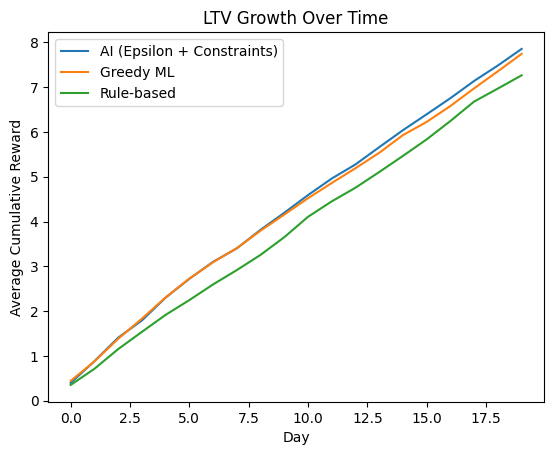

In [63]:
# Cell 11: LTV over time (AI vs Greedy vs Rule)

ai_curve = ai_df.groupby("day")["cumulative_reward"].mean()
greedy_curve = greedy_df.groupby("day")["cumulative_reward"].mean()
rule_curve = rule_df.groupby("day")["cumulative_reward"].mean()

plt.figure()
plt.plot(ai_curve, label="AI (Epsilon + Constraints)")
plt.plot(greedy_curve, label="Greedy ML")
plt.plot(rule_curve, label="Rule-based")

plt.xlabel("Day")
plt.ylabel("Average Cumulative Reward")
plt.title("LTV Growth Over Time")
plt.legend()
plt.show()

In [64]:
# Cell 12: Explore vs exploit ratio

total = agent.explore_count + agent.exploit_count

print("Explore %:", round(agent.explore_count / total, 2))
print("Exploit %:", round(agent.exploit_count / total, 2))

Explore %: 0.06
Exploit %: 0.94


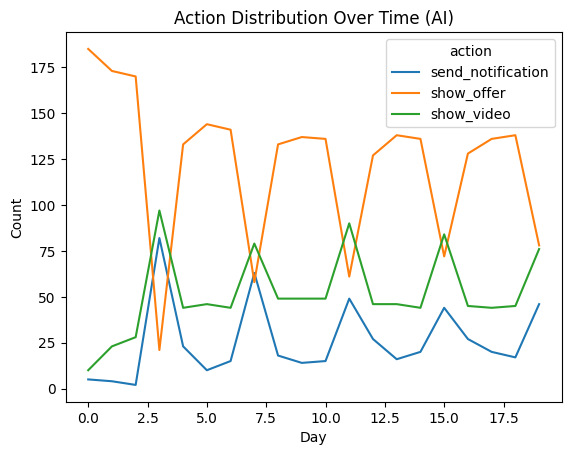

In [65]:
# Cell 13: Action distribution over time (AI)

action_dist = ai_df.groupby(["day", "action"]).size().unstack().fillna(0)

action_dist.plot()
plt.title("Action Distribution Over Time (AI)")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

In [66]:
# Cell 14: Constraint usage

constraint_rate = ai_df["constraint_triggered"].mean()

print("Constraint trigger rate:", round(constraint_rate, 3))

Constraint trigger rate: 0.204


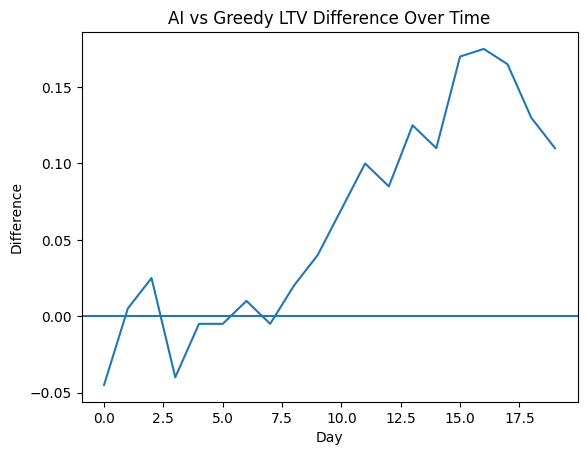

In [67]:
# Cell 15: Difference over time

diff = ai_curve - greedy_curve

plt.figure()
plt.plot(diff)
plt.axhline(0)
plt.title("AI vs Greedy LTV Difference Over Time")
plt.xlabel("Day")
plt.ylabel("Difference")
plt.show()